In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

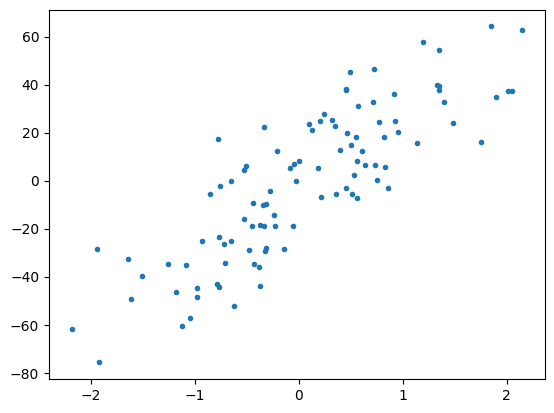

In [6]:
X,y = make_regression(n_features=1, n_informative=1, noise=20, random_state=13)

plt.plot(X,y, '.')
plt.show()

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
lr = LinearRegression()

In [9]:

lr.fit(X,y)
print(f"m = {lr.coef_[0]}\nc = {lr.intercept_}")

m = 27.82809103252014
c = -2.29474455867698


In [10]:
np.mean(cross_val_score(lr,X,y,scoring='r2', cv = 10))

np.float64(0.6375011587464419)

In [11]:
class GD_regression:
    def __init__(self, learning_rate, epochs):
        self._m = 100
        self._b = -120

        self._lr = learning_rate
        self._epochs = epochs

    def fit(self, X,y):
        for i in range(self._epochs):
            predictions = self._m * X.ravel() + self._b
            residuals = y - predictions  # (y - ŷ)
            n = len(y)
            
            # Gradient for b
            gradient_b = (-2 / n) * np.sum(residuals)
            
            # Gradient for m
            gradient_m = (-2 / n) * np.sum(X.ravel() * residuals)
            
            # Update both parameters
            self._b = self._b - (self._lr * gradient_b)
            self._m = self._m - (self._lr * gradient_m)
        
        print(self._m)
        print(self._b)

In [12]:
gd = GD_regression(learning_rate=0.01, epochs=1000)
gd.fit(X,y)


27.828094720862698
-2.29474608273331
